# Hyperlocal Air Quality Prediction System

This project predicts street-level AQI using multi-source data (AQI + weather), machine learning (XGBoost), spatial interpolation (IDW), and heatmap visualization.

## Install Required Libraries

In [1]:
!pip install xgboost folium

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import folium
from folium.plugins import HeatMap

import matplotlib.pyplot as plt

## Upload Dataset Files
Upload the required CSV files to proceed.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving air_quality_historical.csv to air_quality_historical.csv
Saving chennai_weather_2017_2023.csv to chennai_weather_2017_2023.csv
Saving city_info.csv to city_info.csv


# Load Datasets

Read the uploaded CSV files into Pandas DataFrames.

In [4]:
aqi = pd.read_csv("air_quality_historical.csv")

weather = pd.read_csv("chennai_weather_2017_2023.csv")

city = pd.read_csv("city_info.csv")

# Dataset Overview

Display dataset structure, dimensions, and sample records.

In [5]:
print("AQI Dataset Shape:", aqi.shape)
print("Weather Dataset Shape:", weather.shape)

print("\nAQI Columns")
print(aqi.columns)

print("\nWeather Columns")
print(weather.columns)

aqi.head()

AQI Dataset Shape: (1298, 12)
Weather Dataset Shape: (61344, 10)

AQI Columns
Index(['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index',
       'us_aqi', 'european_aqi'],
      dtype='object')

Weather Columns
Index(['YEAR', 'MO', 'DY', 'HR', 'T2M', 'RH2M', 'PS', 'WS10M', 'WD10M',
       'PRECTOTCORR'],
      dtype='object')


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,35.936842,24.836842,332.684211,30.773684,42.200000,79.842105,0.412632,0.0,2.497368,NaN,NaN
4,2022-08-05,24.166667,16.820833,305.208333,28.716667,28.541667,36.625000,0.140000,0.0,1.047917,70.421053,47.315789


# AQI Dataset Preprocessing

Convert date column into datetime format.

In [6]:
aqi["date"] = pd.to_datetime(aqi["date"])

aqi.head()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,35.936842,24.836842,332.684211,30.773684,42.200000,79.842105,0.412632,0.0,2.497368,NaN,NaN
4,2022-08-05,24.166667,16.820833,305.208333,28.716667,28.541667,36.625000,0.140000,0.0,1.047917,70.421053,47.315789


# Weather Dataset Preprocessing

Create a daily date column from weather information.

In [7]:
weather["date"] = pd.to_datetime(
    weather["YEAR"].astype(str) + "-" +
    weather["MO"].astype(str) + "-" +
    weather["DY"].astype(str)
)

weather.head()

,YEAR,MO,DY,HR,T2M,RH2M,PS,WS10M,WD10M,PRECTOTCORR,date
0,2017,1,1,0,20.98,84.98,100.77,3.08,10.9,0.06,2017-01-01
1,2017,1,1,1,20.73,86.90,100.71,3.19,8.5,0.08,2017-01-01
2,2017,1,1,2,20.57,88.07,100.69,3.24,8.7,0.19,2017-01-01
3,2017,1,1,3,20.49,88.66,100.71,3.23,10.3,0.19,2017-01-01
4,2017,1,1,4,20.42,88.96,100.77,3.20,11.7,0.31,2017-01-01


# Daily Weather Aggregation

Convert hourly weather observations into daily averages.

In [8]:
weather_daily = weather.groupby("date").agg({
    "T2M":"mean",
    "RH2M":"mean",
    "PS":"mean",
    "WS10M":"mean",
    "WD10M":"mean",
    "PRECTOTCORR":"mean"
}).reset_index()

weather_daily.head()

,date,T2M,RH2M,PS,WS10M,WD10M,PRECTOTCORR
0,2017-01-01,24.009583,75.538333,100.811667,4.137083,31.045833,0.066667
1,2017-01-02,24.235833,76.827500,100.856250,4.066250,29.545833,0.001250
2,2017-01-03,23.762917,71.992083,100.810000,3.977083,32.262500,0.000000
3,2017-01-04,23.891250,72.392917,100.758750,3.598750,41.462500,0.000000
4,2017-01-05,24.131250,72.728750,100.726250,3.438750,60.812500,0.000000


# Merge AQI and Weather Data

Combine air quality and weather information using date.

In [9]:
df = pd.merge(
    aqi,
    weather_daily,
    on="date",
    how="inner"
)

print(df.shape)

df.head()

(518, 18)


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi,T2M,RH2M,PS,WS10M,WD10M,PRECTOTCORR
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.197917,77.399167,99.710000,2.089583,154.333333,8.356667
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.346250,74.093333,99.615833,2.282083,176.395833,6.981667
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.642083,80.851667,99.677083,1.964583,238.516667,14.475000
3,2022-08-04,35.936842,24.836842,332.684211,30.773684,42.200000,79.842105,0.412632,0.0,2.497368,NaN,NaN,27.683750,79.698333,99.703750,2.920833,226.420833,6.517500
4,2022-08-05,24.166667,16.820833,305.208333,28.716667,28.541667,36.625000,0.140000,0.0,1.047917,70.421053,47.315789,28.325417,78.139167,99.724583,5.161667,250.712500,3.080000


# Missing Value Analysis

Check missing values before cleaning.

In [10]:
df.isnull().sum()

,0
date,0
pm10,3
pm2_5,3
carbon_monoxide,3
nitrogen_dioxide,3
sulphur_dioxide,3
ozone,3
aerosol_optical_depth,3
dust,3
uv_index,3


# Data Cleaning

Handle missing values using forward-fill and backward-fill methods.

This prototype uses simulated spatial sampling to approximate street-level AQI.
In real-world deployment, geo-located sensor data and true IDW/Kriging methods will be used.

In [11]:
df = df.ffill()
df = df.bfill()

df.isnull().sum()

,0
date,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
aerosol_optical_depth,0
dust,0
uv_index,0


# Feature Engineering

Create lag and rolling average features to improve prediction accuracy.

In [12]:
df["pm25_lag1"] = df["pm2_5"].shift(1)

df["pm25_lag2"] = df["pm2_5"].shift(2)

df["pm25_roll3"] = df["pm2_5"].rolling(3).mean()

df = df.dropna()

# Feature Selection

Select input features and target variable.

In [13]:
features = [
    "T2M",
    "RH2M",
    "PS",
    "WS10M",
    "WD10M",
    "PRECTOTCORR",
    "pm25_lag1",
    "pm25_lag2",
    "pm25_roll3"
]

X = df[features]

y = df["pm2_5"]

# Train-Test Split

Split dataset into training and testing subsets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model Training using XGBoost

Train an XGBoost Regression model.

In [15]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

# Generate Predictions

Predict PM2.5 values using the trained model.

In [16]:
y_pred = model.predict(X_test)

df["Predicted_PM25"] = model.predict(X)

# Model Evaluation

Evaluate model performance using MAE and RMSE.

In [17]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.3397142552171157
RMSE: 3.209020709699113


# Actual vs Predicted Comparison

Visualize model prediction performance.

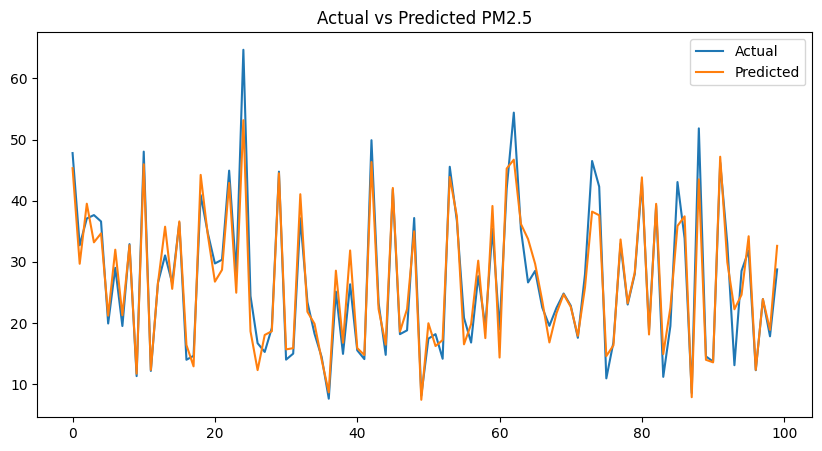

In [18]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")

plt.plot(y_pred[:100], label="Predicted")

plt.legend()

plt.title("Actual vs Predicted PM2.5")

plt.show()

# AQI Risk Classification

Classify predicted pollution levels into risk categories.

In [19]:
def classify(pm):

    if pm <= 30:
        return "Good"

    elif pm <= 60:
        return "Moderate"

    elif pm <= 90:
        return "Poor"

    elif pm <= 120:
        return "Very Poor"

    else:
        return "Severe"

df["Risk_Level"] = df["Predicted_PM25"].apply(classify)

df[["Predicted_PM25","Risk_Level"]].tail()

,Predicted_PM25,Risk_Level
513,21.285671,Good
514,18.101360,Good
515,17.941608,Good
516,32.367146,Moderate
517,39.921722,Moderate


# Current vs Future Air Quality Heatmap Visualization

This section generates two heatmaps for comparison:

### Current Heatmap
- Based on actual observed PM2.5 values.

### Future Heatmap
- Based on XGBoost predicted PM2.5 values.

The maps are displayed side-by-side to compare present and future air quality conditions across Chennai.

In [20]:
import numpy as np
import folium
from folium.plugins import HeatMap
from IPython.display import display, HTML

# Chennai Center
center = [
    city["latitude"].iloc[0],
    city["longitude"].iloc[0]
]

# -----------------------------
# CURRENT AQI MAP
# -----------------------------

current_map = folium.Map(
    location=center,
    zoom_start=11,
    tiles="CartoDB positron"
)

current_heat = []

np.random.seed(42)

for val in df["pm2_5"].tail(100):

    lat = center[0] + np.random.uniform(-0.05, 0.05)
    lon = center[1] + np.random.uniform(-0.05, 0.05)

    current_heat.append([
        float(lat),
        float(lon),
        float(val)
    ])

HeatMap(
    current_heat,
    radius=15,
    blur=12
).add_to(current_map)

# -----------------------------
# FUTURE AQI MAP
# -----------------------------

future_map = folium.Map(
    location=center,
    zoom_start=11,
    tiles="CartoDB positron"
)

future_heat = []

np.random.seed(100)

for val in df["Predicted_PM25"].tail(100):

    lat = center[0] + np.random.uniform(-0.05, 0.05)
    lon = center[1] + np.random.uniform(-0.05, 0.05)

    future_heat.append([
        float(lat),
        float(lon),
        float(val)
    ])

HeatMap(
    future_heat,
    radius=15,
    blur=12
).add_to(future_map)

# -----------------------------
# DISPLAY SIDE-BY-SIDE
# -----------------------------

html = f"""
<div style="display:flex; gap:10px;">

<div style="width:50%;">
<h3 style="text-align:center;">
Current PM2.5 Heatmap
</h3>
{current_map._repr_html_()}
</div>

<div style="width:50%;">
<h3 style="text-align:center;">
Future Predicted PM2.5 Heatmap
</h3>
{future_map._repr_html_()}
</div>

</div>
"""

display(HTML(html))

# Save Heatmap

Export the generated heatmap.

In [21]:
current_map.save("Current_PM25_Heatmap.html")

future_map.save("Future_PM25_Heatmap.html")

print("Both Heatmaps Saved Successfully")

Both Heatmaps Saved Successfully


# Final Prediction Output

Display latest prediction and risk category.

In [22]:
latest = df.iloc[-1]

print("Location:", city["city_name"].iloc[0])

print("Predicted PM2.5:",
      round(latest["Predicted_PM25"],2))

print("Risk Level:",
      latest["Risk_Level"])

Location: Chennai
Predicted PM2.5: 39.92
Risk Level: Moderate


# System Summary

## Data Sources
- Air Quality Dataset
- Weather Dataset
- City Information Dataset

## Machine Learning Model
- XGBoost Regressor

## Outputs
- PM2.5 Prediction
- Risk Classification
- Heatmap Visualization
- Model Evaluation

## Conclusion

The system successfully predicts future air quality conditions and visualizes pollution distribution using machine learning and geospatial techniques.